# Feature Uplift Analysis on MAU

This notebook demonstrates how to analyze and predict the impact of feature changes on Monthly Active Users (MAU). We'll simulate:

- Weekly MAU
- Upward trend + seasonality
- Feature A & B effects (only for Case B)

This approach is useful for A/B testing, feature prioritization, and ROI estimation.

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Create weekly dates
dates = pd.date_range(start="2025-01-01", periods=80, freq='W')

# Base components
trend = np.linspace(10000, 20000, len(dates))  # growing MAU
seasonality = 1000 * np.sin(np.arange(len(dates)) * 2 * np.pi / 12)
noise = np.random.normal(0, 500, len(dates))

# Combine
mau = trend + seasonality + noise

df = pd.DataFrame({
    'ds': dates,
    'y': mau
})

In [16]:
df

,ds,y
0,2025-01-05,10248.357077
1,2025-01-12,10557.450128
2,2025-01-19,11443.034230
3,2025-01-26,12141.261764
4,2025-02-02,11255.277830
...,...,...
75,2026-06-14,20904.622138
76,2026-06-21,20529.802102
77,2026-06-28,20097.331768
78,2026-07-05,19919.298110


## CASE A — Feature NOT live yet

### Train Base Model

In [3]:
from prophet import Prophet

model = Prophet()
model.fit(df)

future = model.make_future_dataframe(periods=12, freq='W')
forecast = model.predict(future)

display(forecast)

08:39:45 - cmdstanpy - INFO - Chain [1] start processing
08:39:46 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-01-05,10053.164485,8981.708625,11148.362496,10053.164485,10053.164485,0.0,0.0,0.0,0.0,0.0,0.0,10053.164485
1,2025-01-12,10175.258725,9187.123501,11221.023887,10175.258725,10175.258725,0.0,0.0,0.0,0.0,0.0,0.0,10175.258725
2,2025-01-19,10297.352964,9354.270985,11320.768299,10297.352964,10297.352964,0.0,0.0,0.0,0.0,0.0,0.0,10297.352964
3,2025-01-26,10419.447204,9307.337668,11502.976436,10419.447204,10419.447204,0.0,0.0,0.0,0.0,0.0,0.0,10419.447204
4,2025-02-02,10541.541443,9498.563385,11636.727333,10541.541443,10541.541443,0.0,0.0,0.0,0.0,0.0,0.0,10541.541443
...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,2026-09-06,21069.559400,20069.264859,22050.279533,21066.120125,21073.088559,0.0,0.0,0.0,0.0,0.0,0.0,21069.559400
88,2026-09-13,21198.804191,20214.485357,22260.988303,21194.601675,21203.062697,0.0,0.0,0.0,0.0,0.0,0.0,21198.804191
89,2026-09-20,21328.048982,20289.482397,22281.128043,21322.962749,21332.918915,0.0,0.0,0.0,0.0,0.0,0.0,21328.048982
90,2026-09-27,21457.293773,20437.132524,22568.702848,21451.388311,21462.805474,0.0,0.0,0.0,0.0,0.0,0.0,21457.293773


### Define feature assumption & apply uplift

In [5]:
feature_a_start = pd.Timestamp("2026-06-01")
feature_b_start = pd.Timestamp("2026-07-01")

uplift_a = 2000
uplift_b = 3000

# Apply uplift to the forecasted values
forecast['yhat_adjusted'] = forecast['yhat']

forecast.loc[forecast['ds'] >= feature_a_start, 'yhat_adjusted'] += uplift_a
forecast.loc[forecast['ds'] >= feature_b_start, 'yhat_adjusted'] += uplift_b

### Plot

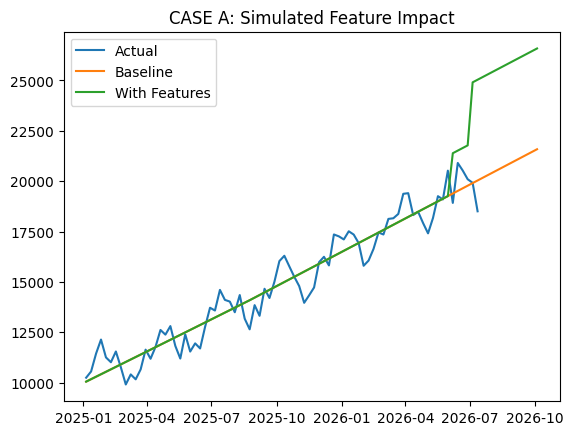

In [6]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(df['ds'], df['y'], label='Actual')
plt.plot(forecast['ds'], forecast['yhat'], label='Baseline')
plt.plot(forecast['ds'], forecast['yhat_adjusted'], label='With Features')

plt.legend()
plt.title("CASE A: Simulated Feature Impact")
plt.show()

## CASE B — Feature IS live (model learns impact)
Now we simulate that features actually affected the past.

In [ ]:
df_case_b = df.copy()

feature_a_start = pd.Timestamp("2025-10-01")
feature_b_start = pd.Timestamp("2025-12-01")

# Flag when features are active
df_case_b['feature_a'] = (df_case_b['ds'] >= feature_a_start).astype(int)
df_case_b['feature_b'] = (df_case_b['ds'] >= feature_b_start).astype(int)

# Add real impact to MAU
# short hand for: df_case_b['y'] = df_case_b['y'] + (df_case_b['feature_a'] * 2000)
df_case_b['y'] += df_case_b['feature_a'] * 2000
df_case_b['y'] += df_case_b['feature_b'] * 3000

In [8]:
df_case_b

,ds,y,feature_a,feature_b
0,2025-01-05,10248.357077,0,0
1,2025-01-12,10557.450128,0,0
2,2025-01-19,11443.034230,0,0
3,2025-01-26,12141.261764,0,0
4,2025-02-02,11255.277830,0,0
...,...,...,...,...
75,2026-06-14,25904.622138,1,1
76,2026-06-21,25529.802102,1,1
77,2026-06-28,25097.331768,1,1
78,2026-07-05,24919.298110,1,1


### Train model with Regressors

In [13]:
model = Prophet()
model.add_regressor('feature_a')
model.add_regressor('feature_b')

model.fit(df_case_b)

09:10:56 - cmdstanpy - INFO - Chain [1] start processing
09:10:56 - cmdstanpy - INFO - Chain [1] done processing


### Predict future

* Past:
  - y = real MAU
  - yhat = how well model explains it
* Future:
  - y = unknown (you don’t have it yet)
  - yhat = your forecast (what you present to stakeholders)

In [ ]:
# make_future_dataframe() → defines WHEN
future = model.make_future_dataframe(periods=12, freq='W')

future['feature_a'] = (future['ds'] >= feature_a_start).astype(int)
future['feature_b'] = (future['ds'] >= feature_b_start).astype(int)

# predict() → computes WHAT
forecast = model.predict(future)

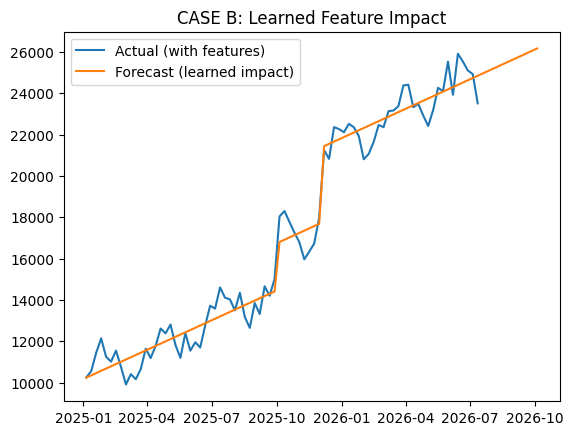

In [15]:
plt.figure()

plt.plot(df_case_b['ds'], df_case_b['y'], label='Actual (with features)')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast (learned impact)')

plt.legend()
plt.title("CASE B: Learned Feature Impact")
plt.show()